In [44]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific, plot_lsp_comparison
from random_sector_combos import make_distinct_sector_combinations

In [52]:
a, b = make_distinct_sector_combinations(
    3,
    f_max=0.5,
    seed=0,
    shuffle=True,
    include_full=True,
)
print(a)

{1: 3, 2: 3, 3: 1}


In [58]:
a, b = make_distinct_sector_combinations(
    6,
    f_max=0.5,
    seed=0,
    shuffle=True,
    include_full=True,
)
print(a)

{1: 6, 2: 15, 3: 4, 4: 3, 5: 1, 6: 1}


In [59]:
a, b = make_distinct_sector_combinations(
    6,
    f_max=1.0,
    seed=0,
    shuffle=True,
    include_full=True,
)
print(a)

{1: 6, 2: 15, 3: 20, 4: 15, 5: 6, 6: 1}


## Load master table

In [3]:
from astropy.table import Table

tbl = Table.read('master_table.fits')

scalar_cols = [name for name in tbl.colnames if len(tbl[name].shape) <= 1]
multi_cols  = [name for name in tbl.colnames if len(tbl[name].shape) >  1]

master_table = tbl[scalar_cols].to_pandas()

for col in multi_cols:
    master_table[col] = list(tbl[col])

print(master_table.shape)
master_table.head()

(868, 26)


,name,rms,std,MAD,sigmaG,skewness,von_neumann_ratio,J_Stetson,max_power,freq_at_max_power,...,SumLSP_7_4_Day_Power,SumLSP_4_1_Day_Power,SumLSP_1_p5_Day_Power,Entropy,sectors,cadence,n_sectors,LOC,AGE,FullPeriodogram
0,b'BMG32',0.061409,0.000668,0.000434,0.000639,0.397087,0.000783,0.935988,0.046111,0.36,...,0.206012,0.528081,0.173964,6.981934,[0],30.0,1,b'LMC',7.9,"[0.026436947727934403, 0.02746316684230981, 0...."
1,b'BMG32',0.161769,0.001006,0.000719,0.001065,-3.085452,0.001452,1.434224,0.174483,0.32,...,0.170952,1.841990,0.271482,6.934397,[1],30.0,1,b'LMC',7.9,"[0.002725964423310637, 0.007146544857656363, 0..."
2,b'BMG32',0.112893,0.001003,0.000626,0.000927,17.266732,0.001003,1.377425,0.174913,0.19,...,0.702348,1.005133,0.103512,7.047517,[2],30.0,1,b'LMC',7.9,"[0.05205991154852454, 0.07989218713552883, 0.0..."
3,b'BMG32',0.119027,0.001056,0.000722,0.001067,-2.638127,0.001146,1.451241,0.112790,0.37,...,0.451855,1.091927,0.113481,7.156956,[3],30.0,1,b'LMC',7.9,"[0.0703332776487653, 0.05668259486342891, 0.03..."
4,b'BMG32',0.061409,0.000850,0.000546,0.000811,-1.767441,0.000560,1.179916,0.068967,0.37,...,0.100536,0.647467,0.117497,7.651595,"[0, 1]",30.0,2,b'LMC',7.9,"[0.006778285831005086, 0.013017152060444029, 0..."


In [4]:
print(master_table.columns)

Index(['name', 'rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio',
       'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks',
       'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation',
       'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power',
       'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power',
       'Entropy', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE',
       'FullPeriodogram'],
      dtype='object')


In [5]:
new_table = master_table[['name', 'sectors', 'cadence', 'n_sectors', 'LOC', 'AGE']].copy()

In [6]:
new_table

,name,sectors,cadence,n_sectors,LOC,AGE
0,b'BMG32',[0],30.0,1,b'LMC',7.90
1,b'BMG32',[1],30.0,1,b'LMC',7.90
2,b'BMG32',[2],30.0,1,b'LMC',7.90
3,b'BMG32',[3],30.0,1,b'LMC',7.90
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90
...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91


## Build updated table

In [7]:
from extract_LC_LSP import add_lightcurves, add_lsps
from invariant_summary_stats import add_variability_metrics
from invariant_LSP import add_invariant_LSP_stats

add_lightcurves(new_table)
add_lsps(new_table, P_min=0.1, P_max=10.0, alpha=5, fap_level=0.01)

[add_lightcurves] processing 868 rows across 55 clusters  |  cadence=30.0 min
[add_lightcurves] done  |  ok=868  missing=0  failed=0
[add_lsps] processing 868 rows  |  P=[0.1, 10.0] days  alpha=5  FAP=0.01  T_effective=True
[add_lsps] done  |  ok=868  skipped=0  failed=0


,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,LSP_power,LSP_FAP
0,b'BMG32',[0],30.0,1,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...","[0.03138590632708135, 0.040288270937488116, 0....",0.025225
1,b'BMG32',[1],30.0,1,b'LMC',7.90,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...","[0.000560826641981916, 0.0031543272050220434, ...",0.026706
2,b'BMG32',[2],30.0,1,b'LMC',7.90,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...","[0.031273467477461146, 0.058572832576034586, 0...",0.023969
3,b'BMG32',[3],30.0,1,b'LMC',7.90,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...","[0.08562990948547124, 0.09200512740769964, 0.0...",0.021693
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...","[0.0031286018190834317, 0.003848817359201781, ...",0.013784
...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20,"[2769.9167884451695, 2769.937622284224, 2769.9...","[0.9998862677333421, 0.999875633701568, 0.9997...","[4.274047492678074e-05, 4.273635535963352e-05,...","[0.1, 0.10426984111967216, 0.10853968223934432...","[0.0028019042016262643, 0.003643753164533522, ...",0.013278
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20,"[2420.0069345704387, 2420.027767841269, 2420.0...","[1.000409940549219, 0.9999722212505378, 1.0001...","[5.2359810627277134e-05, 5.2451677502881545e-0...","[0.1, 0.10276898072228992, 0.10553796144457982...","[0.0019369448212386287, 0.00294436948758637, 0...",0.009036
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91,"[1543.784412772034, 1543.80524656084, 1543.826...","[1.0003120573494295, 1.0006849320573654, 1.000...","[3.471778038086393e-05, 3.448285757645053e-05,...","[0.1, 0.1086174944495052, 0.1172349888990104, ...","[0.10587165306612822, 0.11418969050652931, 0.0...",0.025370
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91,"[1569.451349827374, 1569.472183108963, 1569.49...","[0.9999328665576012, 1.0000060038037917, 1.000...","[3.9436533405072194e-05, 4.0246802399471696e-0...","[0.1, 0.10794052408189338, 0.11588104816378675...","[0.10567532534874734, 0.1424068514684566, 0.12...",0.023970


In [20]:
new_table[(new_table['n_sectors']==5)]

,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,...,n_bins_used,vn_ratio_gap_aware,stetson_j_gap_aware,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
52,b'BSDL2934',"[0, 1, 2, 3, 4]",30.0,5,b'LMC',8.4,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0009479183369714, 1.0011659542205658, 1.000...","[0.0005814099037117012, 0.0005763671391586441,...","[0.1, 0.10159494552260752, 0.10318989104521503...",...,5717.0,1.049416,0.296256,0.017120,1.352032,0.739627,0.030087,0.101488,0.846385,0.867144
127,b'NGC1711',"[0, 1, 2, 3, 4]",30.0,5,b'LMC',7.2,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0001436198115488, 0.9999450598538245, 0.999...","[0.00014433538950349225, 0.0001437527343756122...","[0.1, 0.10155717119873532, 0.10311434239747064...",...,5828.0,0.970731,0.403490,0.029860,1.362866,0.733748,0.045639,0.144112,0.714218,0.853854
206,b'NGC1735',"[4, 5, 6, 7, 8]",10.0,5,b'LMC',7.7,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.999029008513679, 1.0009468651729747, 1.0017...","[0.00022165764952311248, 0.0002216852503330412...","[0.1, 0.101646936053137, 0.103293872106274, 0....",...,5777.0,3.850306,2.202051,0.245503,0.258106,3.874379,0.192142,0.597288,3.273508,0.345066
207,b'NGC1735',"[4, 5, 6, 7, 9]",10.0,5,b'LMC',7.7,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.999029008513679, 1.0009468651729747, 1.0017...","[0.00022165764952311248, 0.0002216852503330412...","[0.1, 0.10162518861336639, 0.10325037722673278...",...,5854.0,3.512903,1.995214,0.213997,0.257643,3.881335,0.144327,0.496228,3.330594,0.367742
208,b'NGC1735',"[4, 5, 6, 8, 9]",10.0,5,b'LMC',7.7,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.999029008513679, 1.0009468651729747, 1.0017...","[0.00022165764952311248, 0.0002216852503330412...","[0.1, 0.10162701802139207, 0.10325403604278414...",...,5844.0,4.361710,2.097145,0.242651,0.257821,3.878664,0.201849,0.582363,3.467277,0.300527
209,b'NGC1735',"[4, 5, 7, 8, 9]",10.0,5,b'LMC',7.7,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.999029008513679, 1.0009468651729747, 1.0017...","[0.00022165764952311248, 0.0002216852503330412...","[0.1, 0.1016512722504819, 0.1033025445009638, ...",...,5798.0,3.417420,2.009882,0.184808,0.258522,3.868141,0.120306,0.544967,3.299969,0.366615
210,b'NGC1735',"[4, 6, 7, 8, 9]",10.0,5,b'LMC',7.7,"[2036.2889686851177, 2036.3098023183538, 2036....","[0.999029008513679, 1.0009468651729747, 1.0017...","[0.00022165764952311248, 0.0002216852503330412...","[0.1, 0.10162418043258334, 0.10324836086516667...",...,5859.0,3.699527,2.125667,0.248536,0.257546,3.882809,0.197928,0.666044,3.178193,0.345029
211,b'NGC1735',"[5, 6, 7, 8, 9]",10.0,5,b'LMC',7.7,"[2061.865338603926, 2061.9000613672383, 2061.9...","[0.9992518031206543, 0.9986931589454389, 0.998...","[0.0002261297664633086, 0.00022610136366025955...","[0.1, 0.10161498154648424, 0.10322996309296846...",...,5888.0,3.476001,2.051313,0.219179,0.258268,3.871944,0.188602,0.617288,3.211813,0.369584
318,b'NGC2093',"[0, 1, 2, 3, 4]",30.0,5,b'LMC',7.7,"[1354.136746704879, 1354.157579840476, 1354.17...","[0.9992654203203853, 1.0001325146304259, 1.000...","[0.0003496370410959914, 0.00034969907633344117...","[0.1, 0.10164439623493404, 0.10328879246986808...",...,5653.0,0.884687,0.410122,0.041617,1.068549,0.935848,0.030448,0.181206,1.004583,0.851139
319,b'NGC2093',"[0, 1, 2, 3, 5]",30.0,5,b'LMC',7.7,"[1354.136746704879, 1354.157579840476, 1354.17...","[0.9992654203203853, 1.0001325146304259, 1.000...","[0.0003496370410959914, 0.00034969907633344117...","[0.1, 0.10163265051779134, 0.10326530103558267...",...,5707.0,0.925882,0.464368,0.044121,1.068162,0.936188,0.019478,0.142583,1.085493,0.943479


In [8]:
add_variability_metrics(new_table)
add_invariant_LSP_stats(new_table)

[add_variability_metrics] processing 868 rows
[add_variability_metrics] done  |  ok=868  skipped=0  failed=0
[add_invariant_LSP_stats] processing 868 rows
[add_invariant_LSP_stats] done  |  ok=868  skipped=0  failed=0


,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,...,n_bins_used,vn_ratio_gap_aware,stetson_j_gap_aware,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
0,b'BMG32',[0],30.0,1,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...",...,1077.0,0.852171,0.293478,0.080666,0.360143,2.776677,0.185001,0.419068,1.005505,0.269574
1,b'BMG32',[1],30.0,1,b'LMC',7.90,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...",...,1027.0,1.525171,0.939781,0.240224,0.317772,3.146912,0.047830,0.298017,2.624035,0.353090
2,b'BMG32',[2],30.0,1,b'LMC',7.90,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...",...,1150.0,1.200405,0.824825,0.237476,0.187344,5.337774,0.444140,1.160263,1.625045,0.133833
3,b'BMG32',[3],30.0,1,b'LMC',7.90,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...",...,1283.0,1.480430,0.945429,0.152587,0.367642,2.720036,0.439434,0.934364,1.873543,0.169371
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.90,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...",...,2104.0,1.193458,0.607867,0.108654,0.374662,2.669069,0.077800,0.356884,2.211132,0.344050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,b'SAURER 6',"[2, 3]",10.0,2,b'MW',9.20,"[2769.9167884451695, 2769.937622284224, 2769.9...","[0.9998862677333421, 0.999875633701568, 0.9997...","[4.274047492678074e-05, 4.273635535963352e-05,...","[0.1, 0.10426984111967216, 0.10853968223934432...",...,2189.0,3.030110,2.388841,0.154791,0.642270,1.556978,0.039292,0.130958,1.229535,1.306176
864,b'SAURER 6',"[1, 2, 3]",10.0,3,b'MW',9.20,"[2420.0069345704387, 2420.027767841269, 2420.0...","[1.000409940549219, 0.9999722212505378, 1.0001...","[5.2359810627277134e-05, 5.2451677502881545e-0...","[0.1, 0.10276898072228992, 0.10553796144457982...",...,3405.0,2.590834,2.016855,0.076556,0.642720,1.555887,0.094592,0.236637,1.091622,1.165372
865,b'VDBERGH-HAGEN 92',[0],30.0,1,b'MW',8.91,"[1543.784412772034, 1543.80524656084, 1543.826...","[1.0003120573494295, 1.0006849320573654, 1.000...","[3.471778038086393e-05, 3.448285757645053e-05,...","[0.1, 0.1086174944495052, 0.1172349888990104, ...",...,1084.0,1.287765,1.848983,0.131199,0.246497,4.056838,0.390390,0.676576,1.260146,0.390746
866,b'VDBERGH-HAGEN 92',[1],30.0,1,b'MW',8.91,"[1569.451349827374, 1569.472183108963, 1569.49...","[0.9999328665576012, 1.0000060038037917, 1.000...","[3.9436533405072194e-05, 4.0246802399471696e-0...","[0.1, 0.10794052408189338, 0.11588104816378675...",...,1150.0,2.572295,2.589437,0.142407,0.107941,9.264361,0.478879,0.554786,0.793889,0.320582


## Save

In [17]:
# from astropy.table import Table
# import numpy as np

# # LC arrays are large intermediates — drop before saving; regenerate with add_lightcurves()
# save_table = new_table.drop(columns=['LC_t', 'LC_x', 'LC_err_x'])

# # Separate scalar columns from per-row array columns
# def _is_array_col(series):
#     first = next((v for v in series if v is not None), None)
#     return isinstance(first, (np.ndarray, list))

# scalar_cols = [c for c in save_table.columns if not _is_array_col(save_table[c])]
# array_cols  = [c for c in save_table.columns if     _is_array_col(save_table[c])]

# tbl = Table.from_pandas(save_table[scalar_cols])
# for col in array_cols:
#     tbl[col] = [v if v is not None else np.array([]) for v in save_table[col]]

# tbl.write('new_master_table.fits', overwrite=True)
# print(f"Saved {len(tbl)} rows  |  columns: {tbl.colnames}")

# VISUALIZE

In [9]:
from vis_statistics import plot_cluster_statistics, plot_clusters_comparison
from vis_lc import get_lc_path, plot_cluster_lcs
from vis_periodogram import plot_cluster_periodograms, plot_cluster_periodograms_specific

In [11]:
new_table.head()

,name,sectors,cadence,n_sectors,LOC,AGE,LC_t,LC_x,LC_err_x,LSP_freq,...,n_bins_used,vn_ratio_gap_aware,stetson_j_gap_aware,LSP_max_power,LSP_freq_at_max_power,LSP_period_at_max_power,LSP_SumPow_10_7,LSP_SumPow_7_4,LSP_SumPow_4_1,LSP_SumPow_1_p5
0,b'BMG32',[0],30.0,1,b'LMC',7.9,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10839170102580067, 0.11678340205160134...",...,1077.0,0.852171,0.293478,0.080666,0.360143,2.776677,0.185001,0.419068,1.005505,0.269574
1,b'BMG32',[1],30.0,1,b'LMC',7.9,"[1410.9283805553364, 1410.9492137124166, 1411....","[0.9959518989804473, 0.9967784422446525, 0.998...","[0.0005083746925240335, 0.0005079584784039902,...","[0.1, 0.1090738263391421, 0.1181476526782842, ...",...,1027.0,1.525171,0.939781,0.240224,0.317772,3.146912,0.047830,0.298017,2.624035,0.353090
2,b'BMG32',[2],30.0,1,b'LMC',7.9,"[1569.447644895273, 1569.468478380938, 1569.48...","[1.0013508768642108, 0.9995276507017979, 0.998...","[0.001107691177440487, 0.0011245434875321722, ...","[0.1, 0.1079403652130463, 0.1158807304260926, ...",...,1150.0,1.200405,0.824825,0.237476,0.187344,5.337774,0.444140,1.160263,1.625045,0.133833
3,b'BMG32',[3],30.0,1,b'LMC',7.9,"[1653.948830404778, 1653.969663983743, 1653.99...","[1.000487143665834, 1.000670471719181, 1.00029...","[0.0004794438707843265, 0.0004792852712212794,...","[0.1, 0.10704321537201596, 0.1140864307440319,...",...,1283.0,1.480430,0.945429,0.152587,0.367642,2.720036,0.439434,0.934364,1.873543,0.169371
4,b'BMG32',"[0, 1]",30.0,2,b'LMC',7.9,"[1382.0534040342682, 1382.0742371425345, 1382....","[1.0000975450628886, 0.9998390715786509, 0.998...","[0.0006122919607540418, 0.0006073373966713103,...","[0.1, 0.10435972165094515, 0.10871944330189029...",...,2104.0,1.193458,0.607867,0.108654,0.374662,2.669069,0.077800,0.356884,2.211132,0.344050


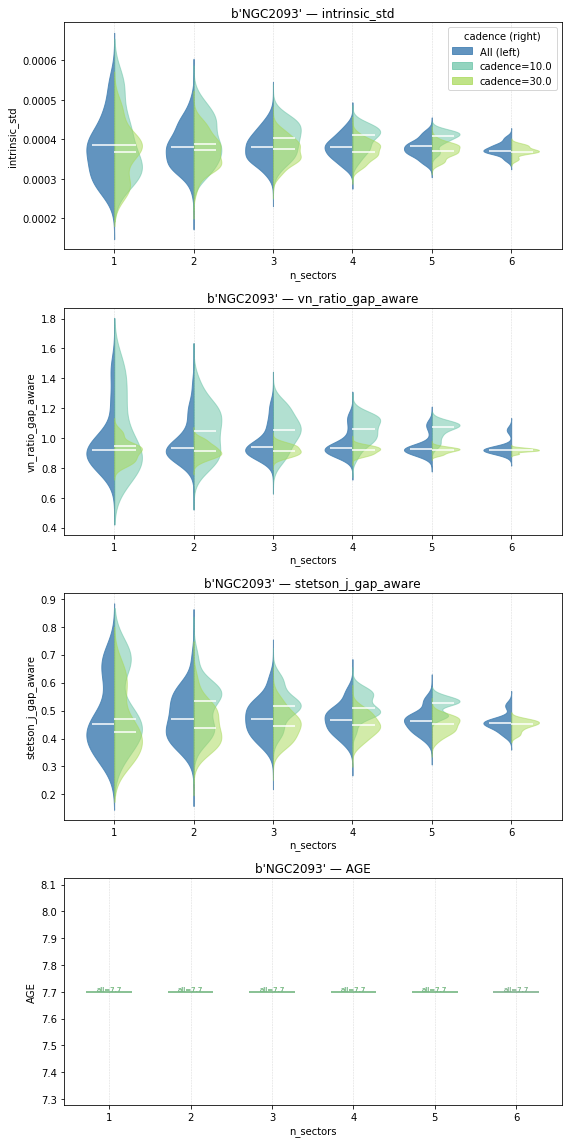

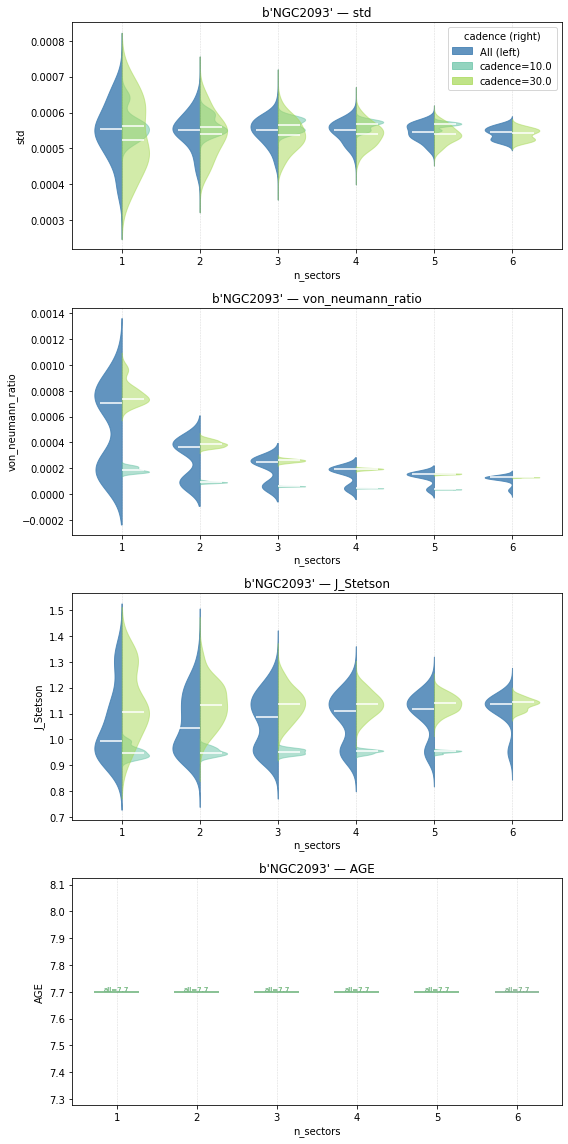

In [23]:
#cluster_name = b'NGC2093'
#cluster_name = b'BMG32'
cluster_name = b'[SL63] 730'
cluster_name = b'NGC2160'
cluster_name = b'NGC2093'	

plot_cluster_statistics(
  new_table,
  name=cluster_name,
  #statistics_list=['rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio', 'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks', 'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation', 'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power', 'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power', 'Entropy', 'AGE'],
  statistics_list=['intrinsic_std', 'vn_ratio_gap_aware', 'stetson_j_gap_aware', 'AGE'],

    max_n_sectors=6
)

plot_cluster_statistics(
  master_table,
  name=cluster_name,
  #statistics_list=['rms', 'std', 'MAD', 'sigmaG', 'skewness', 'von_neumann_ratio', 'J_Stetson', 'max_power', 'freq_at_max_power', 'n_peaks', 'ratio_of_power_at_high_v_low_freq', 'FAP', 'max_autocorrelation', 'time_of_max_autocorrelation', 'SumLSP_10_7_Day_Power', 'SumLSP_7_4_Day_Power', 'SumLSP_4_1_Day_Power', 'SumLSP_1_p5_Day_Power', 'Entropy', 'AGE'],
  statistics_list=['std', 'von_neumann_ratio', 'J_Stetson', 'AGE'],

    max_n_sectors=6
)